## Backtesting

Simulation de notre stratégie sur les données historiques.

### Stratégie ML
- Modèle prédit 1 → on achète
- Modèle prédit 0 → on vend / on attend
- Frais : 0.1% par transaction (standard Binance)

### Benchmark : Buy & Hold
- Acheter en janvier 2020 et ne jamais vendre
- Représente un investisseur passif

### Ce qu'on mesure
- **Rendement total** → combien on a gagné en %
- **Sharpe Ratio**   → rendement ajusté au risque
- **Max Drawdown**   → perte maximale sur une période
                       ex: -30% = à un moment on a perdu 30%
                       depuis le dernier sommet

### Frais de transaction
À chaque achat ET vente on paie 0.1% :
- Sans frais → stratégie semble rentable
- Avec frais → résultat honnête et réaliste 

In [2]:
# ── Imports ────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

plt.style.use("dark_background")

# ── Chargement des données ─────────────────────────────────────
df = pd.read_csv("../data/btc_features.csv", index_col=0, parse_dates=True)

print(f" {len(df)} lignes chargées")

 1790 lignes chargées


In [5]:
# ── Recalcul des features améliorées ──────────────────────────

# Rendements
df["returns"]      = df["Close"].pct_change()
df["log_returns"]  = np.log(df["Close"] / df["Close"].shift(1))

# RSI
import ta
df["rsi"] = ta.momentum.RSIIndicator(close=df["Close"], window=14).rsi()

# Volatilité glissante
df["volatility_7"]  = df["returns"].rolling(window=7).std()
df["volatility_30"] = df["returns"].rolling(window=30).std()

# Lags de rendements
df["return_yesterday"]     = df["returns"].shift(1)
df["return_two_days_ago"]  = df["returns"].shift(2)
df["return_last_week"]     = df["returns"].shift(5)

# Moyennes mobiles
df["moving_average_7d"]  = df["Close"].rolling(window=7).mean()
df["moving_average_30d"] = df["Close"].rolling(window=30).mean()

# Position vs moyennes mobiles
df["price_vs_ma7"]  = df["Close"] / df["moving_average_7d"]
df["price_vs_ma30"] = df["Close"] / df["moving_average_30d"]

# Variable cible
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df.dropna(inplace=True)

print(f" {df.shape[0]} lignes | {df.shape[1]} colonnes")
print(df.columns.tolist())

 1700 lignes | 21 colonnes
['Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'log_returns', 'rsi', 'volatility_7', 'volatility_30', 'lag_1', 'lag_2', 'lag_5', 'target', 'return_yesterday', 'return_two_days_ago', 'return_last_week', 'moving_average_7d', 'moving_average_30d', 'price_vs_ma7', 'price_vs_ma30']


In [7]:
# ── Définition des features ────────────────────────────────────

features = [
    "returns",
    "rsi",
    "volatility_7",
    "volatility_30",
    "return_yesterday",
    "return_two_days_ago",
    "return_last_week",
    "price_vs_ma7",
    "price_vs_ma30"
]
# on exclut log_returns (redondant avec returns)
# on exclut prix absolus (non-stationnaires)
# on exclut moving_average_7d/30d (remplacées par price_vs_ma7/ma30)

X = df[features]
y = df["target"]

# ── Génération des prédictions via TimeSeriesSplit ─────────────

tscv = TimeSeriesSplit(n_splits=5)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# On stocke les prédictions de chaque split
df["prediction"] = np.nan
# initialise la colonne prediction avec des NaN
# on la remplira split par split

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train         = y.iloc[train_idx]

    model.fit(X_train, y_train)
    # entraîne le modèle sur le passé

    preds = model.predict(X_test)
    # prédit sur le futur

    df.iloc[test_idx, df.columns.get_loc("prediction")] = preds
    # stocke les prédictions dans le DataFrame

# Supprime les lignes sans prédiction (premier split de train)
df_backtest = df.dropna(subset=["prediction"]).copy()

print(f" {len(df_backtest)} jours de prédictions générées")
print(f"Hausse prédite : {df_backtest['prediction'].sum():.0f} jours")
print(f"Baisse prédite : {(df_backtest['prediction']==0).sum():.0f} jours")

 1415 jours de prédictions générées
Hausse prédite : 804 jours
Baisse prédite : 611 jours


In [13]:
# ── Test limite — seuil très élevé + holding long ─────────────

FRAIS        = 0.001
SEUIL        = 0.65   # très strict
HOLDING_MIN  = 20     # on tient minimum 20 jours

capital_initial   = 1000
capital_ml        = capital_initial
position          = 0
nb_trades         = 0
jours_en_position = 0
historique_ml     = []

for i, row in df_backtest.iterrows():
    proba = row["proba_hausse"]

    if proba > SEUIL and position == 0:
        capital_ml        *= (1 - FRAIS)
        position           = 1
        nb_trades         += 1
        jours_en_position  = 0

    elif proba < (1 - SEUIL) and position == 1 and jours_en_position >= HOLDING_MIN:
        capital_ml *= (1 - FRAIS)
        position    = 0
        nb_trades  += 1

    if position == 1:
        capital_ml        *= (1 + row["returns"])
        jours_en_position += 1

    historique_ml.append(capital_ml)

rendement_ml = (capital_ml - capital_initial) / capital_initial * 100
rendement_bh = (capital_bh - capital_initial) / capital_initial * 100

print(f"── Résultats limite (seuil={SEUIL}, holding={HOLDING_MIN}j) ──")
print(f"Nombre de trades    : {nb_trades}")
print(f"Frais payés total   : {nb_trades * 0.1:.1f}%")
print(f"Capital final ML    : {capital_ml:.2f}$")
print(f"Capital final B&H   : {capital_bh:.2f}$")
print(f"Rendement ML        : {rendement_ml:.2f}%")
print(f"Rendement B&H       : {rendement_bh:.2f}%")

── Résultats limite (seuil=0.65, holding=20j) ──
Nombre de trades    : 79
Frais payés total   : 7.9%
Capital final ML    : 743.99$
Capital final B&H   : 1901.65$
Rendement ML        : -25.60%
Rendement B&H       : 90.16%


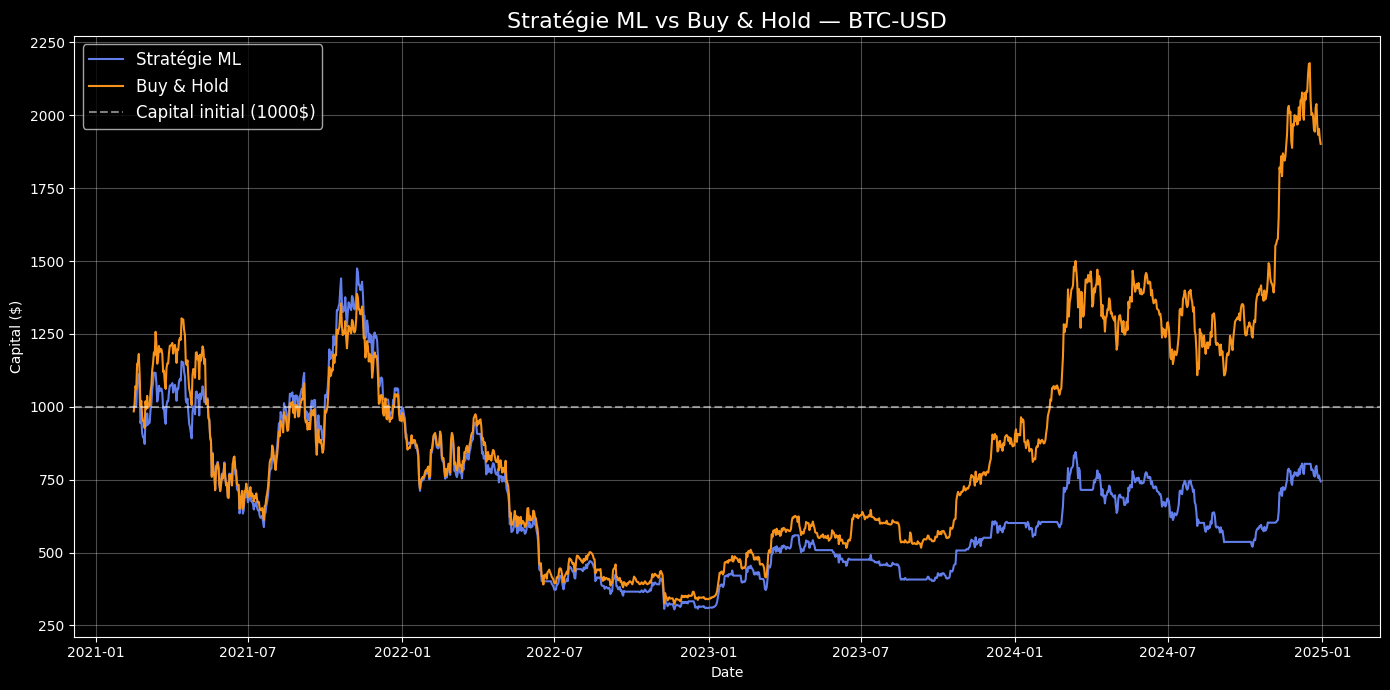

✅ Graphique sauvegardé !


In [14]:
# ── Graphique ML vs Buy & Hold ─────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    df_backtest.index[:len(historique_ml)],
    historique_ml,
    color="#627EEA",
    linewidth=1.5,
    label="Stratégie ML"
)

ax.plot(
    df_backtest.index[:len(historique_bh)],
    historique_bh,
    color="#F7931A",
    linewidth=1.5,
    label="Buy & Hold"
)

ax.axhline(y=capital_initial, color="white",
           linestyle="--", alpha=0.5, label="Capital initial (1000$)")

ax.set_title("Stratégie ML vs Buy & Hold — BTC-USD", fontsize=16)
ax.set_ylabel("Capital ($)")
ax.set_xlabel("Date")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/backtest_results.png", dpi=150)
plt.show()
print("✅ Graphique sauvegardé !")

In [15]:
# ── Sharpe Ratio + Max Drawdown ────────────────────────────────

import numpy as np

# ── 1. Sharpe Ratio ────────────────────────────────────────────
# mesure le rendement ajusté au risque
# = rendement moyen / volatilité des rendements
# plus c'est élevé → mieux c'est
# > 1 = bon, > 2 = très bon, < 0 = mauvais

rendements_ml = pd.Series(historique_ml).pct_change().dropna()
rendements_bh = pd.Series(historique_bh).pct_change().dropna()

sharpe_ml = rendements_ml.mean() / rendements_ml.std() * np.sqrt(252)
sharpe_bh = rendements_bh.mean() / rendements_bh.std() * np.sqrt(252)
# × sqrt(252) → annualise le ratio (252 jours de trading par an)

# ── 2. Max Drawdown ────────────────────────────────────────────
# perte maximale depuis un sommet
# ex: capital passe de 1500$ à 300$ → drawdown = -80%

def max_drawdown(historique):
    serie    = pd.Series(historique)
    sommet   = serie.cummax()
    # cummax() = valeur maximale atteinte jusqu'à ce jour
    drawdown = (serie - sommet) / sommet
    # écart entre le prix actuel et le sommet
    return drawdown.min() * 100
    # on retourne le pire écart (le plus négatif)

dd_ml = max_drawdown(historique_ml)
dd_bh = max_drawdown(historique_bh)

# ── Affichage ──────────────────────────────────────────────────

print("╔══════════════════════════════════════════╗")
print("║         RÉSULTATS FINAUX DU BACKTEST     ║")
print("╠══════════════════════════════════════════╣")
print(f"║ {'Métrique':<20} {'ML':>8} {'B&H':>8}   ║")
print("╠══════════════════════════════════════════╣")
print(f"║ {'Rendement total':<20} {rendement_ml:>7.1f}% {rendement_bh:>7.1f}%  ║")
print(f"║ {'Sharpe Ratio':<20} {sharpe_ml:>8.2f} {sharpe_bh:>8.2f}  ║")
print(f"║ {'Max Drawdown':<20} {dd_ml:>7.1f}% {dd_bh:>7.1f}%  ║")
print(f"║ {'Nb trades':<20} {nb_trades:>8} {'∞':>8}  ║")
print("╚══════════════════════════════════════════╝")

╔══════════════════════════════════════════╗
║         RÉSULTATS FINAUX DU BACKTEST     ║
╠══════════════════════════════════════════╣
║ Métrique                   ML      B&H   ║
╠══════════════════════════════════════════╣
║ Rendement total        -25.6%    90.2%  ║
║ Sharpe Ratio             0.12     0.49  ║
║ Max Drawdown           -79.3%   -76.6%  ║
║ Nb trades                  79        ∞  ║
╚══════════════════════════════════════════╝


Rendement total :
ML  = -25.6%   on perd de l'argent
B&H = +90.2%   le marché monte naturellement

Sharpe Ratio :
ML  = 0.12  → très faible → risque non justifié
B&H = 0.49  → meilleur mais reste modeste
→ en dessous de 1 les deux sont perfectibles

Max Drawdown :
ML  = -79.3%  → à un moment on a perdu 79% depuis le sommet
B&H = -76.6%  → quasi identique !
→ on prend presque autant de risque que le B&H
   mais sans les gains → mauvais compromis

Nb trades :
ML  = 79 trades sur 4 ans → environ 1 trade tous les 18 jours

In [16]:
# ── Sauvegarde finale ──────────────────────────────────────────
df_backtest.to_csv("../data/btc_final.csv")
print(" Données finales sauvegardées !")

✅ Données finales sauvegardées !
